<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/22_complete_case_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/data_science_job.csv")

In [138]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [139]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [140]:
df.shape

(19158, 13)

In [141]:
list=[(df.isnull().mean()*100)<5]


In [142]:
list

[enrollee_id                True
 city                       True
 city_development_index     True
 gender                    False
 relevent_experience        True
 enrolled_university        True
 education_level            True
 major_discipline          False
 experience                 True
 company_size              False
 company_type              False
 training_hours             True
 target                     True
 dtype: bool]

In [143]:
cols=[i for i in df.columns if df[i].isnull().mean()*100<5 and df[i].isnull().mean()*100>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [144]:
df.shape

(19158, 13)

In [145]:
df[cols].dropna().shape

(17182, 5)

In [146]:
df[cols].sample(5).head()

,city_development_index,enrolled_university,education_level,experience,training_hours
12036,0.550,no_enrollment,Masters,9.0,18.0
11776,0.926,no_enrollment,Masters,15.0,75.0
15138,0.855,no_enrollment,Masters,13.0,202.0
4954,0.910,Full time course,Graduate,9.0,55.0
9085,0.878,no_enrollment,Graduate,3.0,NaN


In [147]:
new_df=df[cols].dropna()

In [148]:
new_df.shape

(17182, 5)

In [149]:
df.shape

(19158, 13)

/tmp/ipykernel_189/1415238936.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[cols].hist(ax=ax,color="red", bins=50)


array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

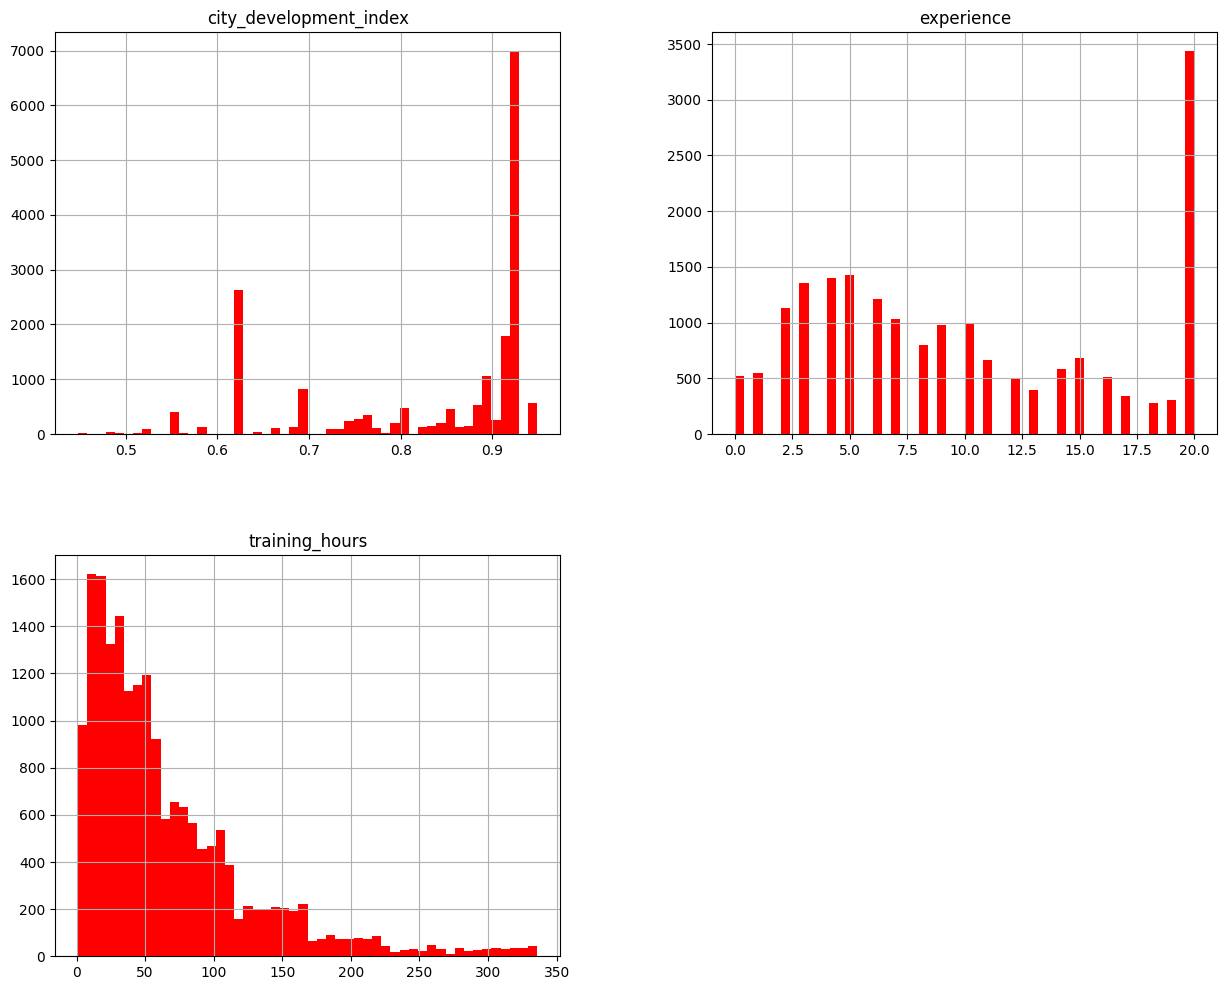

In [150]:
fig=plt.figure(figsize=(15,12))
ax=fig.add_subplot(121)

df[cols].hist(ax=ax,color="red", bins=50)

<Axes: >

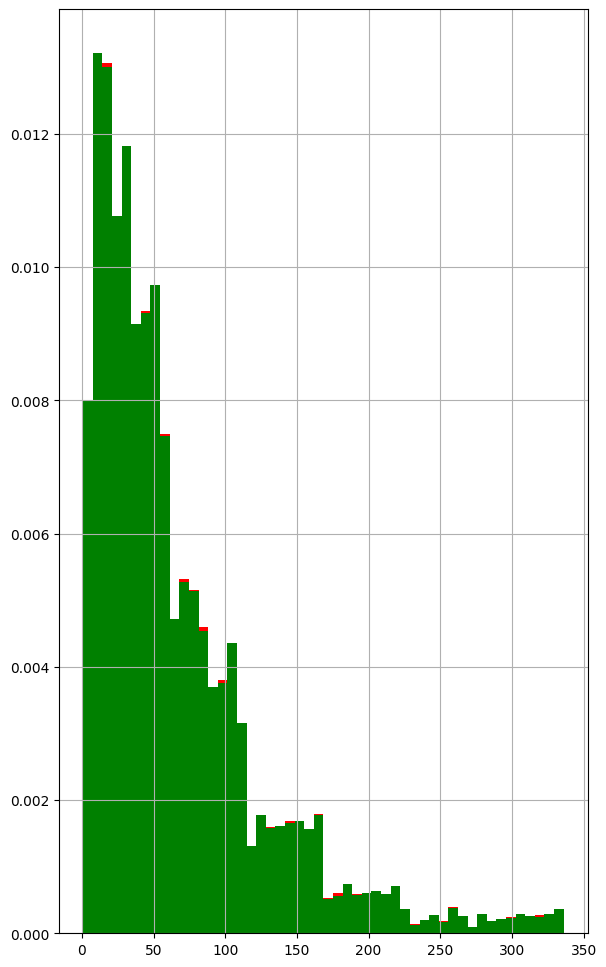

In [151]:
fig=plt.figure(figsize=(15,12))
ax=fig.add_subplot(121)

df["training_hours"].hist(ax=ax,color="red",density=True, bins=50)
new_df["training_hours"].hist(ax=ax,color="green",density=True, bins=50)

(array([8.00907579e-03, 1.32123691e-02, 1.30125765e-02, 1.07714251e-02,
        1.18138211e-02, 9.14702474e-03, 9.31207077e-03, 9.72902916e-03,
        7.46181790e-03, 4.71684182e-03, 5.28147298e-03, 5.14248684e-03,
        4.54310915e-03, 3.70050574e-03, 3.75262553e-03, 4.35200322e-03,
        3.16193448e-03, 1.31168161e-03, 1.78075980e-03, 1.58096724e-03,
        1.60702714e-03, 1.65914694e-03, 1.68520684e-03, 1.57228061e-03,
        1.77207317e-03, 5.21197991e-04, 5.64631157e-04, 7.38363821e-04,
        5.82004423e-04, 5.99377690e-04, 6.34124222e-04, 5.90691056e-04,
        7.03617288e-04, 3.64838594e-04, 1.30299498e-04, 1.99792563e-04,
        2.77972262e-04, 1.73732664e-04, 3.73525227e-04, 2.51912362e-04,
        8.68663318e-05, 2.95345528e-04, 1.91105930e-04, 2.08479196e-04,
        2.34539096e-04, 2.86658895e-04, 2.51912362e-04, 2.43225729e-04,
        2.95345528e-04, 3.64838594e-04]),
 array([  1. ,   7.7,  14.4,  21.1,  27.8,  34.5,  41.2,  47.9,  54.6,
         61.3,  68. ,  

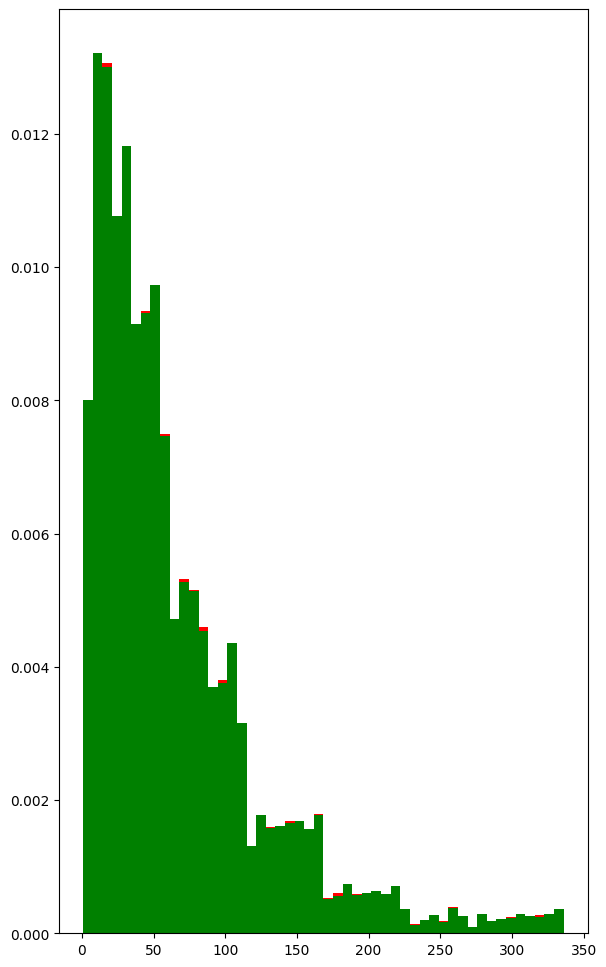

In [152]:
fig=plt.figure(figsize=(15,12))
ax=plt.subplot(121)
plt.hist(df["training_hours"],bins=50, density=True,color="red")
plt.hist(new_df["training_hours"],bins=50,density=True, color="green")


<Axes: ylabel='Density'>

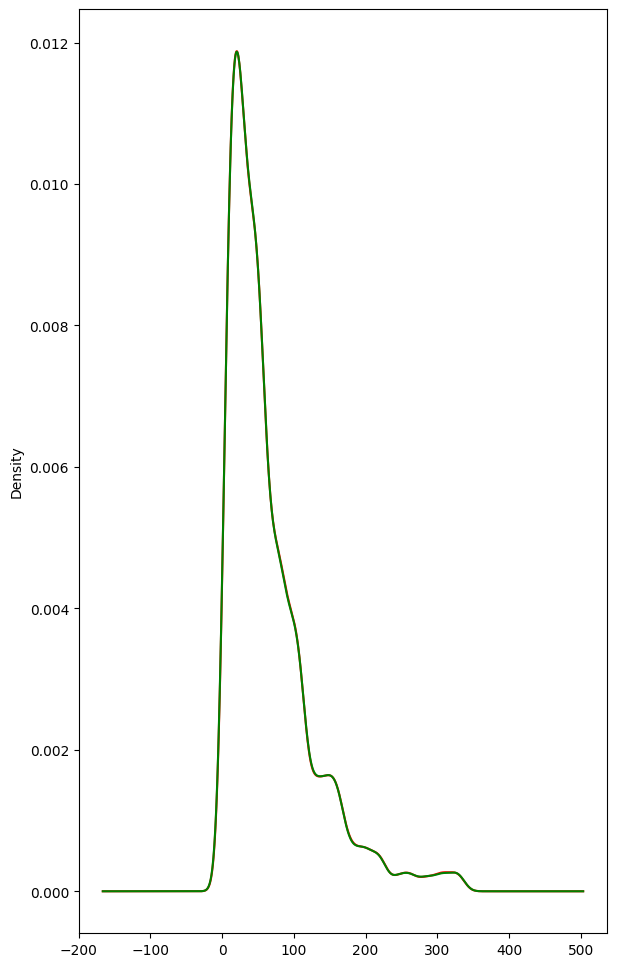

In [153]:
fig=plt.figure(figsize=(15,12))
ax=fig.add_subplot(121)

df["training_hours"].plot.density(color="red")
new_df["training_hours"].plot.density(color="green")

<Axes: xlabel='training_hours', ylabel='Density'>

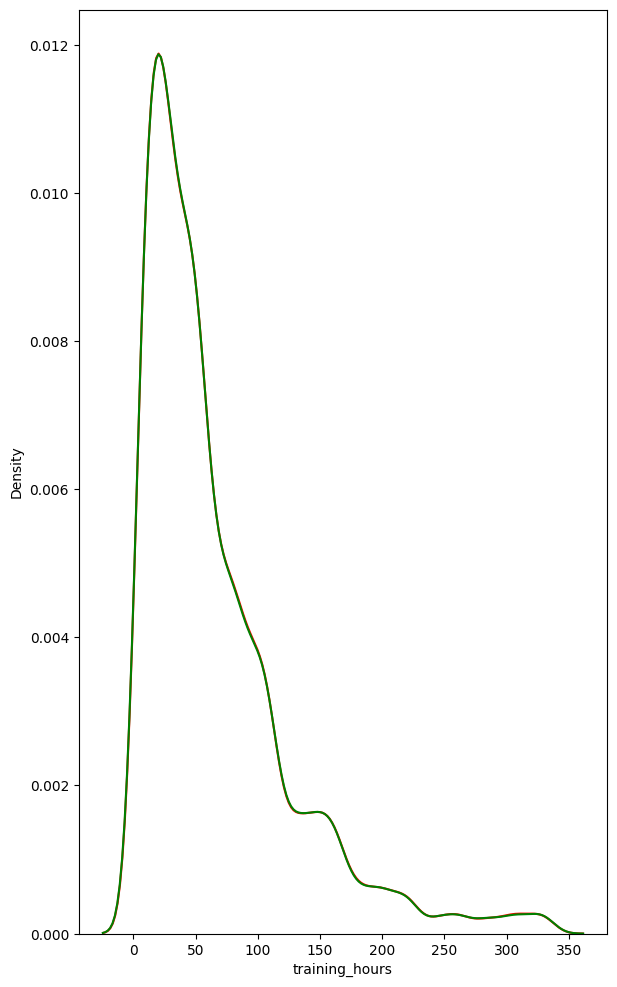

In [154]:
fig=plt.figure(figsize=(15,12))
ax=fig.add_subplot(121)

sns.kdeplot(df["training_hours"],color="red")
sns.kdeplot(new_df["training_hours"],color="green")

(array([9.29348380e-02, 0.00000000e+00, 0.00000000e+00, 1.10360120e-01,
        7.55095559e-02, 0.00000000e+00, 1.27785402e-01, 4.82099472e-01,
        0.00000000e+00, 0.00000000e+00, 2.03875801e+00, 5.22758464e-02,
        0.00000000e+00, 6.56352294e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.37601645e+01, 0.00000000e+00, 2.49762377e-01,
        1.74252821e-02, 5.86651165e-01, 0.00000000e+00, 6.67969148e-01,
        4.03685703e+00, 4.64674190e-02, 0.00000000e+00, 5.16950037e-01,
        4.82099472e-01, 1.25462031e+00, 1.47534055e+00, 1.82965462e+00,
        6.15693302e-01, 8.13179833e-02, 1.02228322e+00, 2.48019849e+00,
        0.00000000e+00, 7.26053422e-01, 8.13179833e-01, 1.09198435e+00,
        2.42792264e+00, 6.85394431e-01, 7.72520841e-01, 2.88678841e+00,
        5.68064198e+00, 1.41144785e+00, 9.64779787e+00, 3.78941802e+01,
        0.00000000e+00, 3.00295695e+00]),
 array([0.448  , 0.45802, 0.46804, 0.47806, 0.48808, 0.4981 , 0.50812,
        0.51814, 0.5281

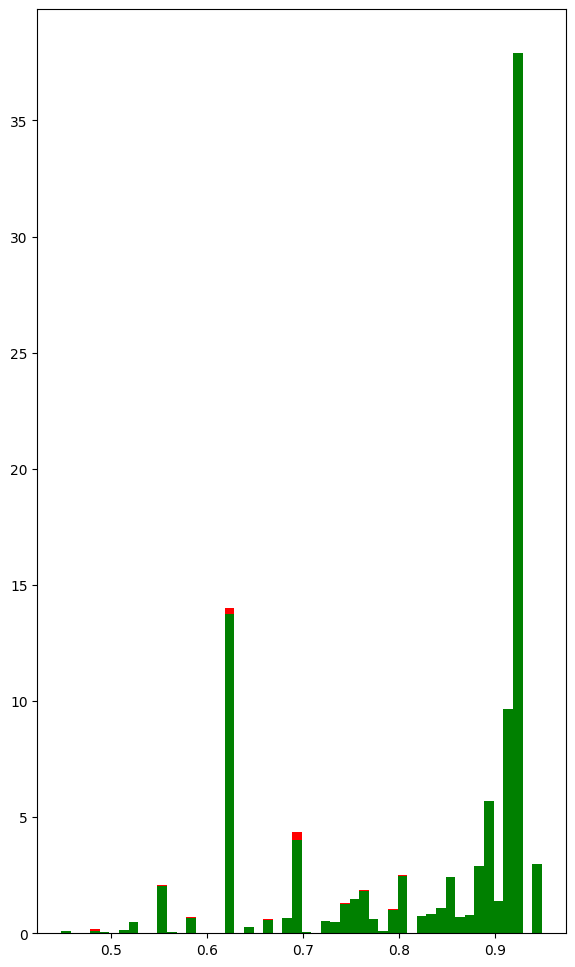

In [155]:
fig=plt.figure(figsize=(15,12))
ax=plt.subplot(121)
plt.hist(df["city_development_index"],bins=50, density=True,color="red")
plt.hist(new_df["city_development_index"],bins=50,density=True, color="green")


In [156]:
new_df

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


In [157]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [158]:
df["city_development_index"].dropna().shape

(18679,)

In [162]:
temp=pd.concat(
    [df["enrolled_university"].value_counts()/len(df),
    new_df["enrolled_university"].value_counts()/len(new_df)],axis=1
)

In [163]:
temp

,count,count
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [164]:
temp=pd.concat(
    [df["education_level"].value_counts()/len(df),
    new_df["education_level"].value_counts()/len(new_df)],axis=1
)
temp



,count,count
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
